# MIT-BIH ECG Arrhythmia Classification Demo

**Dataset:**
https://www.kaggle.com/datasets/shayanfazeli/heartbeat

- this dataset is a preprocessed derivative of the **MIT-BIH Arrhythmia Database** intended for educational purposes
- files used: ```mitbih_train.csv```, ```mitbih_test.csv```

```
+-------+------------------------------------+-------------------------------------------------------------+
| Class | Arrhythmia Type                    | Typical ECG Morphology                                      |
+-------+------------------------------------+-------------------------------------------------------------+
|   0   | Normal Beat (N)                    | Regular rhythm, standard P-QRS-T structure, stable shape    |
|       |                                    | and timing                                                  |
+-------+------------------------------------+-------------------------------------------------------------+
|   1   | Supraventricular Ectopic Beat (S)  | Premature beat, often narrower QRS complex, altered P-wave  |
|       |                                    | morphology, originates above ventricles                     |
+-------+------------------------------------+-------------------------------------------------------------+
|   2   | Ventricular Ectopic Beat (V)       | Wide and distorted QRS complex, abnormal ventricular origin,|
|       |                                    | often no clear preceding P-wave                             |
+-------+------------------------------------+-------------------------------------------------------------+
|   3   | Fusion Beat (F)                    | Hybrid morphology combining characteristics of normal and   |
|       |                                    | ventricular beats                                           |
+-------+------------------------------------+-------------------------------------------------------------+
|   4   | Unknown / Unclassifiable Beat (Q)  | Irregular or noisy morphology that does not clearly match   |
|       |                                    | other categories                                            |
+-------+------------------------------------+-------------------------------------------------------------+
```


**Pipeline:**
1. Load & inspect ECG heartbeat dataset
    - load data, visualize signal, inspect class balance
2. Feature extraction
3. Feature selection
4. Model train&eval with interpretation/explanation
    1. Decision Tree
    2. RIPPER
    3. XGBoost




## 1. Load & inspect dataset

Train shape: (87554, 188)
Test shape : (21892, 188)


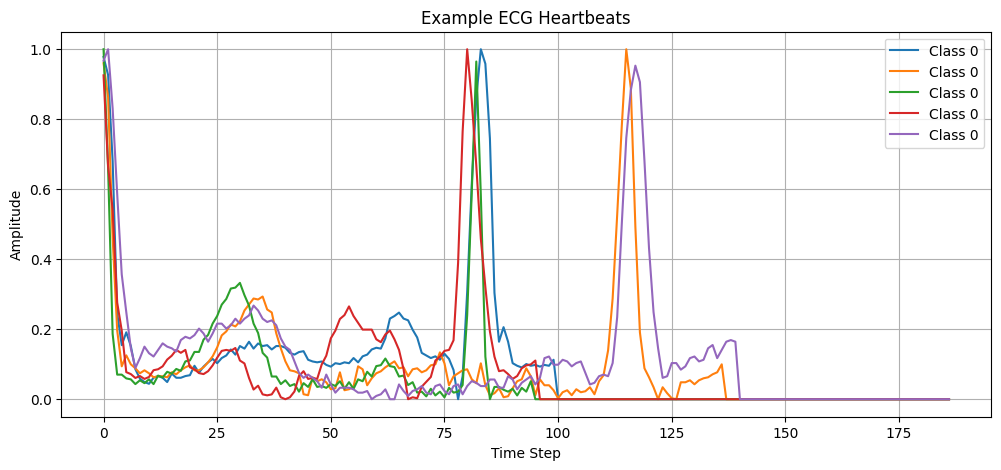

Detected classes: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


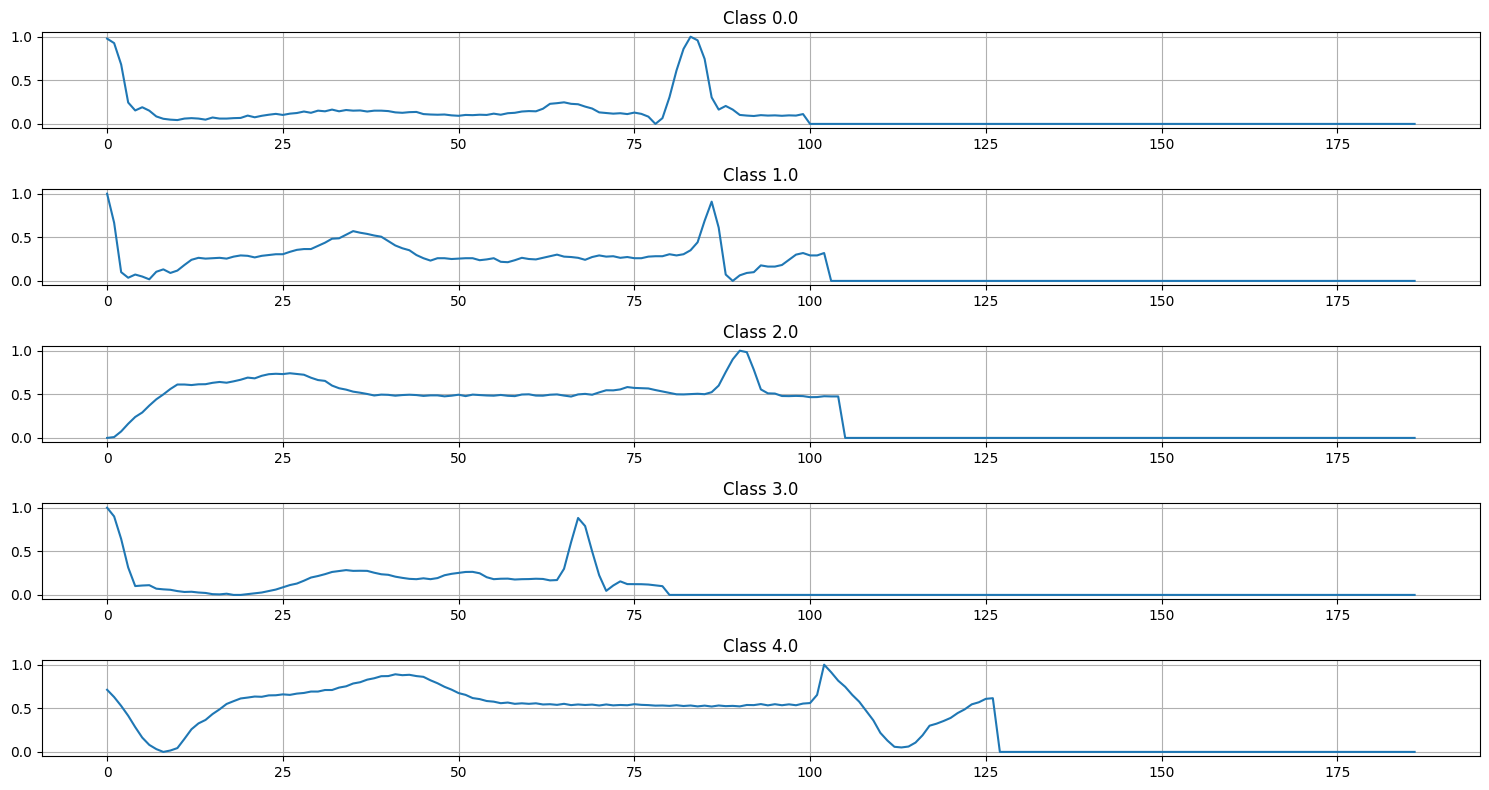

Class distribution:

Class 0: 72471 samples
Class 1: 2223 samples
Class 2: 5788 samples
Class 3: 641 samples
Class 4: 6431 samples


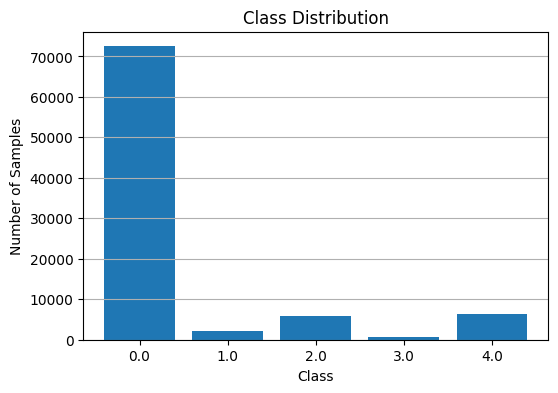

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis
from scipy.signal import welch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier
from xgboost import plot_importance


# ============================================================
# LOAD DATASET
# ============================================================

train_df = pd.read_csv("./ECGArrh/mitbih_train.csv", header=None)
test_df  = pd.read_csv("./ECGArrh/mitbih_test.csv", header=None)

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


# Last column = class label
X_train_raw = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test_raw = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

# ============================================================
# VISUALIZE ECG SIGNALS
# ============================================================

plt.figure(figsize=(12,5))

for i in range(5):
    plt.plot(X_train_raw[i], label=f"Class {int(y_train[i])}")

plt.title("Example ECG Heartbeats")
plt.xlabel("Time Step")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()


# Show one sample from each class

# remove possible NaN labels
classes = sorted(pd.Series(y_train).dropna().unique())

print("Detected classes:", classes)

plt.figure(figsize=(15,8))

plot_idx = 1

for c in classes:

    indices = np.where(y_train == c)[0]

    # skip empty classes
    if len(indices) == 0:
        continue

    sample_idx = indices[0]

    plt.subplot(len(classes), 1, plot_idx)

    plt.plot(X_train_raw[sample_idx])

    plt.title(f"Class {c}")

    plt.grid(True)

    plot_idx += 1

plt.tight_layout()
plt.show()


# ============================================================
# CLASS DISTRIBUTION
# ============================================================

class_counts = pd.Series(y_train).value_counts().sort_index()

print("Class distribution:\n")

for cls, count in class_counts.items():
    print(f"Class {int(cls)}: {count} samples")


plt.figure(figsize=(6,4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.grid(axis='y')

plt.show()

*Note: we see that distribution is heavily imbalanced which will most likely affect the results for minority classes. We will have to carefully inspect **confusion matrix** output, and most likely apply **weighing** or **under/oversampling** when training our models.*

## 2. Feature extraction

We extract several well known and widely used features (e.g. **statistical**, **shape**, **frequency-domain**,  **band power**).

In [4]:
from scipy.stats import skew, kurtosis
from scipy.signal import welch, find_peaks


# ============================================================
# FEATURE EXTRACTION
# ============================================================

def extract_features(signal):

    signal = np.asarray(signal).astype(np.float64)

    features = []

    # ========================================================
    # BASIC STATISTICAL FEATURES
    # ========================================================

    mean_val = np.mean(signal)
    std_val = np.std(signal)

    min_val = np.min(signal)
    max_val = np.max(signal)

    median_val = np.median(signal)

    iqr_val = (
        np.percentile(signal, 75)
        - np.percentile(signal, 25)
    )

    mean_abs_val = np.mean(np.abs(signal))

    peak_to_peak = np.ptp(signal)

    rms = np.sqrt(np.mean(signal**2))

    energy = np.sum(signal**2)

    abs_area = np.sum(np.abs(signal))

    features.extend([
        mean_val,
        std_val,
        min_val,
        max_val,
        median_val,
        iqr_val,
        mean_abs_val,
        peak_to_peak,
        rms,
        energy,
        abs_area
    ])


    # ========================================================
    # DISTRIBUTION FEATURES
    # ========================================================

    sk = skew(signal)

    if np.isnan(sk):
        sk = 0

    kurt = kurtosis(signal)

    if np.isnan(kurt):
        kurt = 0

    features.extend([
        sk,
        kurt
    ])


    # ========================================================
    # TEMPORAL / SHAPE FEATURES
    # ========================================================

    # zero crossings
    zero_crossings = np.sum(
        np.diff(np.sign(signal)) != 0
    )

    # waveform length
    waveform_length = np.sum(
        np.abs(np.diff(signal))
    )

    # mean absolute difference
    mean_abs_diff = np.mean(
        np.abs(np.diff(signal))
    )

    # slope energy
    slope_energy = np.sum(
        np.diff(signal)**2
    )

    # crest factor
    if rms == 0:
        crest_factor = 0
    else:
        crest_factor = (
            np.max(np.abs(signal)) / rms
        )

    features.extend([
        zero_crossings,
        waveform_length,
        mean_abs_diff,
        slope_energy,
        crest_factor
    ])


    # ========================================================
    # PEAK FEATURES
    # ========================================================

    peaks, properties = find_peaks(signal)

    peak_count = len(peaks)

    if peak_count > 0:

        peak_heights = signal[peaks]

        mean_peak_height = np.mean(peak_heights)

        std_peak_height = np.std(peak_heights)

        max_peak_height = np.max(peak_heights)

    else:

        mean_peak_height = 0
        std_peak_height = 0
        max_peak_height = 0

    features.extend([
        peak_count,
        mean_peak_height,
        std_peak_height,
        max_peak_height
    ])


    # ========================================================
    # HJORTH PARAMETERS
    # ========================================================

    first_deriv = np.diff(signal)

    second_deriv = np.diff(first_deriv)

    var_zero = np.var(signal)

    var_d1 = np.var(first_deriv)

    var_d2 = np.var(second_deriv)

    # activity
    hjorth_activity = var_zero

    # mobility
    if var_zero == 0:
        hjorth_mobility = 0
    else:
        hjorth_mobility = np.sqrt(
            var_d1 / var_zero
        )

    # complexity
    if var_d1 == 0 or hjorth_mobility == 0:
        hjorth_complexity = 0
    else:
        hjorth_complexity = (
            np.sqrt(var_d2 / var_d1)
            / hjorth_mobility
        )

    features.extend([
        hjorth_activity,
        hjorth_mobility,
        hjorth_complexity
    ])


    # ========================================================
    # SHANNON ENTROPY
    # ========================================================

    hist, _ = np.histogram(
        signal,
        bins=20,
        density=True
    )

    hist = hist + 1e-12

    shannon_entropy = -np.sum(
        hist * np.log2(hist)
    )

    features.append(shannon_entropy)


    # ========================================================
    # FREQUENCY DOMAIN FEATURES
    # ========================================================

    freqs, psd = welch(
        signal,
        nperseg=min(128, len(signal))
    )

    psd_sum = np.sum(psd)

    if psd_sum == 0:
        psd_norm = np.ones_like(psd) / len(psd)
    else:
        psd_norm = psd / psd_sum


    # dominant frequency
    dominant_freq = freqs[np.argmax(psd)]

    # spectral entropy
    spectral_entropy = -np.sum(
        psd_norm * np.log2(psd_norm + 1e-12)
    )

    # spectral centroid
    spectral_centroid = np.sum(
        freqs * psd_norm
    )

    # spectral bandwidth
    spectral_bandwidth = np.sqrt(
        np.sum(
            ((freqs - spectral_centroid)**2)
            * psd_norm
        )
    )

    # spectral rolloff (85%)
    cumulative_psd = np.cumsum(psd_norm)

    rolloff_idx = np.where(
        cumulative_psd >= 0.85
    )[0]

    if len(rolloff_idx) > 0:
        spectral_rolloff = freqs[rolloff_idx[0]]
    else:
        spectral_rolloff = 0


    features.extend([
        dominant_freq,
        spectral_entropy,
        spectral_centroid,
        spectral_bandwidth,
        spectral_rolloff
    ])


    # ========================================================
    # BAND POWERS
    # ========================================================

    low_band = np.sum(
        psd[(freqs >= 0) & (freqs < 5)]
    )

    mid_band = np.sum(
        psd[(freqs >= 5) & (freqs < 15)]
    )

    high_band = np.sum(
        psd[(freqs >= 15)]
    )

    features.extend([
        low_band,
        mid_band,
        high_band
    ])


    # nan check cause scipy sometime does odd things
    features = np.nan_to_num(
        features,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return features


# ============================================================
# EXTRACT FEATURES
# ============================================================

X_train_features = np.array([
    extract_features(x)
    for x in X_train_raw
])

X_test_features = np.array([
    extract_features(x)
    for x in X_test_raw
])

print("Feature matrix shape:", X_train_features.shape)


# ============================================================
# FEATURE NAMES
# ============================================================

feature_names = [

    # statistical
    "mean",
    "std",
    "min",
    "max",
    "median",
    "iqr",
    "mean_abs",
    "peak_to_peak",
    "rms",
    "energy",
    "abs_area",

    # distribution
    "skewness",
    "kurtosis",

    # temporal
    "zero_crossings",
    "waveform_length",
    "mean_abs_diff",
    "slope_energy",
    "crest_factor",

    # peaks
    "peak_count",
    "mean_peak_height",
    "std_peak_height",
    "max_peak_height",

    # hjorth
    "hjorth_activity",
    "hjorth_mobility",
    "hjorth_complexity",

    # entropy
    "shannon_entropy",

    # spectral
    "dominant_freq",
    "spectral_entropy",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",

    # band powers
    "low_band_power",
    "mid_band_power",
    "high_band_power"
]

Feature matrix shape: (87554, 34)


## 3. Feature selection

- two methods:
    1. ANOVA-F (```f_classif```)
    2. Mutual Information (```mutual_info_classif```)

- comparison of top 20 selected features


In [5]:
from sklearn.feature_selection import (
    SelectKBest,
    f_classif,
    mutual_info_classif
)

TOP_K = 20


# ============================================================
# ANOVA F-SELECTION
# ============================================================

anova_selector = SelectKBest(
    score_func=f_classif,
    k=TOP_K
)

X_train_anova = anova_selector.fit_transform(
    X_train_features,
    y_train
)

X_test_anova = anova_selector.transform(
    X_test_features
)

anova_mask = anova_selector.get_support()

anova_features = np.array(feature_names)[anova_mask]

anova_scores = pd.DataFrame({
    "Feature": feature_names,
    "ANOVA_F": anova_selector.scores_
})

anova_scores = anova_scores.sort_values(
    by="ANOVA_F",
    ascending=False
)

print("\n==============================")
print("TOP ANOVA FEATURES")
print("==============================")

print(anova_scores.head(20))



# ============================================================
# MUTUAL INFORMATION SELECTION
# ============================================================

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=TOP_K
)

X_train_mi = mi_selector.fit_transform(
    X_train_features,
    y_train
)

X_test_mi = mi_selector.transform(
    X_test_features
)

mi_mask = mi_selector.get_support()

mi_features = np.array(feature_names)[mi_mask]

mi_scores = pd.DataFrame({
    "Feature": feature_names,
    "Mutual_Info": mi_selector.scores_
})

mi_scores = mi_scores.sort_values(
    by="Mutual_Info",
    ascending=False
)

print("\n==============================")
print("TOP MUTUAL INFORMATION FEATURES")
print("==============================")

print(mi_scores.head(20))


# ============================================================
# COMPARE FEATURE OVERLAP
# ============================================================

anova_set = set(anova_features)

mi_set = set(mi_features)

common_features = anova_set.intersection(mi_set)

only_anova = anova_set - mi_set

only_mi = mi_set - anova_set


print("\n==============================")
print("COMMON FEATURES")
print("==============================")

for f in sorted(common_features):
    print("-", f)


print("\n==============================")
print("ONLY IN ANOVA")
print("==============================")

for f in sorted(only_anova):
    print("-", f)


print("\n==============================")
print("ONLY IN MUTUAL INFO")
print("==============================")

for f in sorted(only_mi):
    print("-", f)



overlap_percent = (
    len(common_features) / TOP_K
) * 100

print("\n==============================")
print("OVERLAP")
print("==============================")

print(f"Common features: {len(common_features)}")
print(f"Overlap percentage: {overlap_percent:.2f}%")

C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [32 33] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw



TOP ANOVA FEATURES
              Feature      ANOVA_F
24  hjorth_complexity  9181.222267
23    hjorth_mobility  4300.205327
25    shannon_entropy  3162.094169
16       slope_energy  2974.565556
1                 std  2570.223604
4              median  2554.389371
22    hjorth_activity  2500.863997
17       crest_factor  2400.909505
5                 iqr  2291.771188
8                 rms  2284.122562
11           skewness  2218.452036
19   mean_peak_height  2149.137696
12           kurtosis  1975.905093
6            mean_abs  1971.933873
0                mean  1971.933873
10           abs_area  1971.933873
27   spectral_entropy  1690.232667
9              energy  1650.593119
28  spectral_centroid  1414.349271
30   spectral_rolloff  1272.837672

TOP MUTUAL INFORMATION FEATURES
              Feature  Mutual_Info
24  hjorth_complexity     0.179775
23    hjorth_mobility     0.140391
12           kurtosis     0.114547
11           skewness     0.112263
4              median     0.109400
16

*Both ANOVA F-score and Mutual Information produced highly similar
feature rankings, suggesting stable and meaningful discriminative
signal characteristics across ECG heartbeat classes. We can use either selection, or the 19 that are present in both. For simplicity, we use those selected by ANOVA_F.*

## 4. Training & evaluation

### **DECISION TREE**


DECISION TREE RESULTS
Accuracy: 0.9016992508678969

Classification Report:
              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     18118
         1.0       0.90      0.07      0.13       556
         2.0       0.62      0.53      0.57      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.84      0.73      0.78      1608

    accuracy                           0.90     21892
   macro avg       0.66      0.46      0.49     21892
weighted avg       0.89      0.90      0.89     21892



C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Nikolina\source\DAP_demos\.venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(r

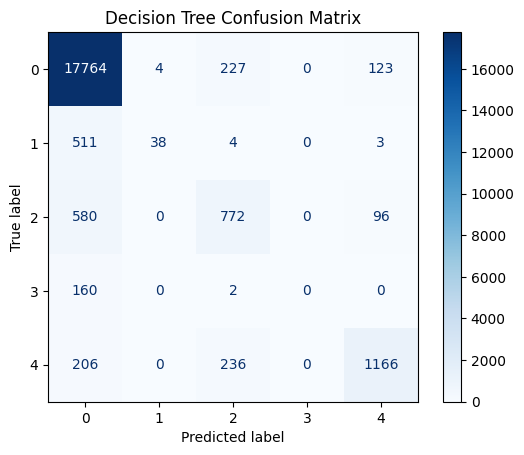

In [6]:
dt_model = DecisionTreeClassifier(
    max_depth=5, # we dont want too deep trees if we want to be able to interpret them
    random_state=42 #for reproducibilty
)

dt_model.fit(X_train_anova, y_train)

y_pred_dt = dt_model.predict(X_test_anova)

print("\n==============================")
print("DECISION TREE RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()




***NOTICE!** Although the overall accuracy is relatively high (~90%), the results for minority classes (particularly Classes 1 and 3) are much worse.*

***Class 1** achieves high precision but extremely **low recall**, meaning the model predicts this arrhythmia only rarely and **misses most true cases**. **Class 3** has precision, recall, and F1-score equal to 0, indicating that the model completely **failed to detect** this class.*

*This demonstrates an important issue in biomedical machine learning: high **overall accuracy can be misleading** when the dataset is strongly imbalanced. Minority pathological classes are often the most clinically important, yet also the most difficult to detect.*


**Possible solution:** class weighing during learning.


DECISION TREE (adjusted weight) RESULTS
Accuracy: 0.7175680613922895

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.71      0.82     18118
         1.0       0.16      0.62      0.25       556
         2.0       0.41      0.74      0.53      1448
         3.0       0.08      0.83      0.15       162
         4.0       0.59      0.82      0.69      1608

    accuracy                           0.72     21892
   macro avg       0.44      0.74      0.49     21892
weighted avg       0.88      0.72      0.77     21892



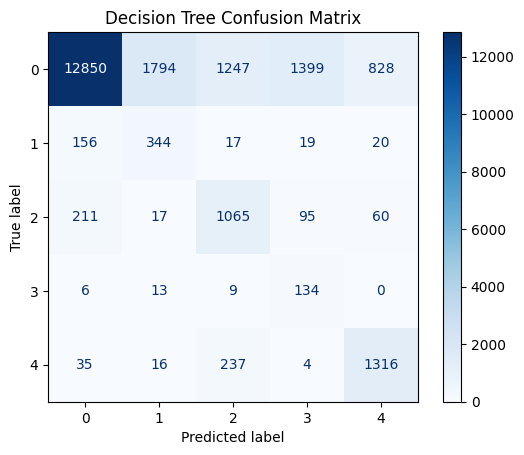

In [7]:
#=======================================
# DT with class weighting
#======================================

dt_model = DecisionTreeClassifier(
    max_depth=5,  # we dont want too deep trees if we want to be able to interpret them
    random_state=42,
    class_weight="balanced"

    #The “balanced” mode uses the values of y to automatically adjust weights
    #inversely proportional to class frequencies in the input data as n_samples / (n_classes * np.bincount(y))
)

dt_model.fit(X_train_anova, y_train)

y_pred_dt = dt_model.predict(X_test_anova)

print("\n==============================")
print("DECISION TREE (adjusted weight) RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))


cm = confusion_matrix(y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.show()




*Notice that the **overall accuracy decreased** after enabling class balancing.
However, this does not necessarily mean that the model became worse.
Previously, the model achieved high accuracy mainly by correctly predicting the dominant
Class 0 (normal heartbeat), while largely ignoring minority arrhythmia classes. After enabling
balanced class weights, the model started paying much more attention to minority classes
(especially Classes 1 and 3), resulting in **significantly higher recall** for these clinically important categories.*

*This demonstrates an important concept in biomedical machine learning: maximizing overall
accuracy is not always the main goal, especially when rare pathological classes are important.*

#### Interpretability - DECISION TREE VISUALIZATION

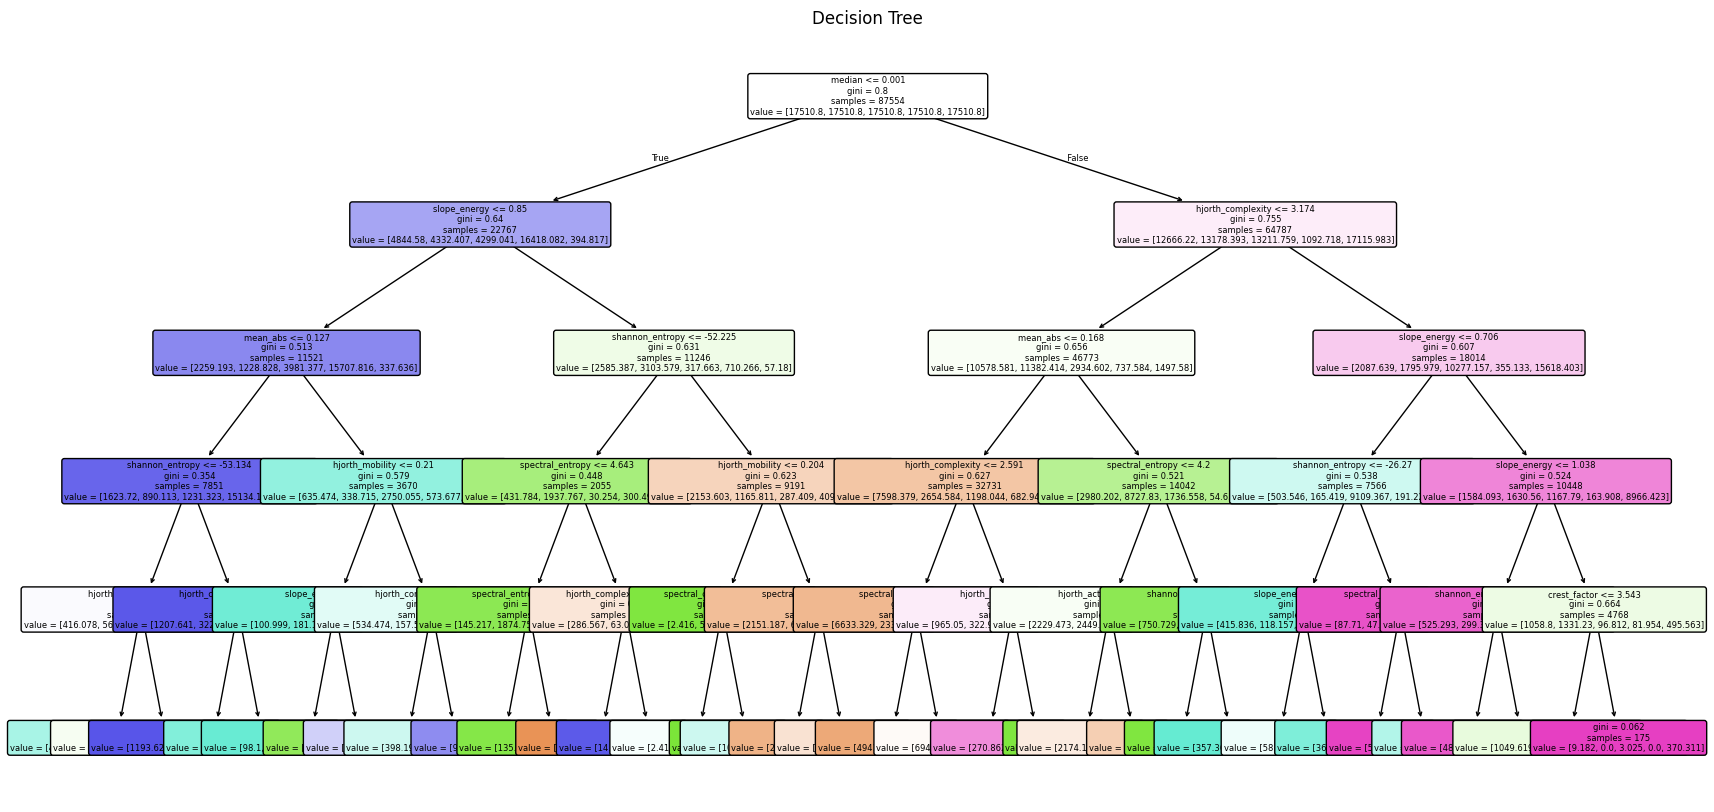

In [8]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    feature_names=anova_features,
    filled=True,
    rounded=True,
    fontsize=6
)

plt.title("Decision Tree")
plt.show()

### **RIPPER** RULE-BASED CLASSIFIER
- using wittgenstein (https://pypi.org/project/wittgenstein/0.1.6/) ```pip install wittgenstein```
- **NOTE:** RIPPER is a binary classification algorithm so we will adapt the problem to *normal vs. abnormal*


RIPPER RESULTS
Accuracy: 0.8683994153115293

Classification Report:
              precision    recall  f1-score   support

           0       0.86      1.00      0.93     18118
           1       0.95      0.25      0.39      3774

    accuracy                           0.87     21892
   macro avg       0.91      0.62      0.66     21892
weighted avg       0.88      0.87      0.83     21892



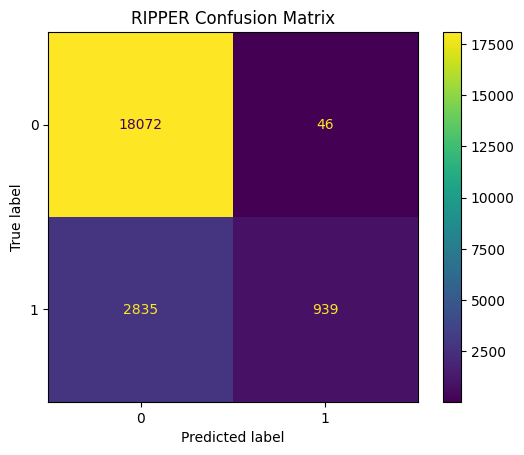


INTERPRETABLE RULES

RULE 1
IF
   hjorth_complexity >= 4.88
   AND
   spectral_entropy=2.82-3.19
   AND
   shannon_entropy >= -27.58
THEN
   Abnormal heartbeat

RULE 2
IF
   hjorth_complexity >= 4.88
   AND
   spectral_rolloff=0.031-0.039
   AND
   median >= 0.39
THEN
   Abnormal heartbeat

RULE 3
IF
   hjorth_complexity >= 4.88
   AND
   slope_energy <= 0.5
   AND
   median >= 0.39
THEN
   Abnormal heartbeat

RULE 4
IF
   hjorth_complexity >= 4.88
   AND
   median=0.29-0.39
   AND
   iqr=0.37-0.47
THEN
   Abnormal heartbeat

RULE 5
IF
   hjorth_mobility <= 0.23
   AND
   slope_energy=0.5-0.6
   AND
   energy >= 31.94
THEN
   Abnormal heartbeat



In [13]:
import wittgenstein as lw

##########################################
# Binary task: normal vs abnormal heartbeat
# 0 = normal heartbeat
# 1 = abnormal heartbeat
###################################
y_train_binary = (y_train != 0).astype(int)
y_test_binary = (y_test != 0).astype(int)


# RIPPER works with pandas DataFrames
X_train_ripper = pd.DataFrame(
    X_train_anova,
    columns=anova_features
)

X_test_ripper = pd.DataFrame(
    X_test_anova,
    columns=anova_features
)

ripper_model = lw.RIPPER(
    random_state=42,
    k=1,
    dl_allowance=4,
    max_rules=5, #we lower the number of rules and conditions to keep some interpretability
    max_rule_conds=3
)

ripper_model.fit(
    X_train_ripper,
    y_train_binary,
    pos_class=1
)


y_pred_ripper = ripper_model.predict(X_test_ripper)


print("\n==============================")
print("RIPPER RESULTS")
print("==============================")
print("Accuracy:", accuracy_score(y_test_binary, y_pred_ripper))
print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_ripper))

cm = confusion_matrix(y_test_binary, y_pred_ripper)
disp = ConfusionMatrixDisplay(cm)

disp.plot()
plt.title("RIPPER Confusion Matrix")
plt.show()


# ============================================================
# PRETTY PRINT RIPPER RULES
# ============================================================

rules = str(ripper_model.ruleset_)
rules = rules.strip("[]")
rule_list = rules.split(" V ")

print("\n==============================")
print("INTERPRETABLE RULES")
print("==============================\n")

for idx, rule in enumerate(rule_list, start=1):

    rule = rule.strip("[]")
    conditions = rule.split("^")

    print(f"RULE {idx}")
    print("IF")

    for c_idx, cond in enumerate(conditions):

        # nicer operators
        cond = cond.replace("=>", " >= ")
        cond = cond.replace("<=", " <= ")
        cond = cond.replace("=<", " <= ")

        if c_idx < len(conditions) - 1:
            print(f"   {cond}")
            print("   AND")
        else:
            print(f"   {cond}")

    print("THEN")
    print("   Abnormal heartbeat\n")

*Although the problem was simplified into normal vs abnormal classification, the abnormal class still contains multiple physiologically different arrhythmia types. This creates a heterogeneous positive class, which can make compact rule-based learning more difficult.*

### **XGBOOST**


XGBOOST RESULTS
Accuracy: 0.9671112735245752

Classification Report:
              precision    recall  f1-score   support

         0.0       0.97      0.99      0.98     18118
         1.0       0.89      0.58      0.70       556
         2.0       0.92      0.87      0.90      1448
         3.0       0.82      0.63      0.71       162
         4.0       0.97      0.93      0.95      1608

    accuracy                           0.97     21892
   macro avg       0.91      0.80      0.85     21892
weighted avg       0.97      0.97      0.97     21892



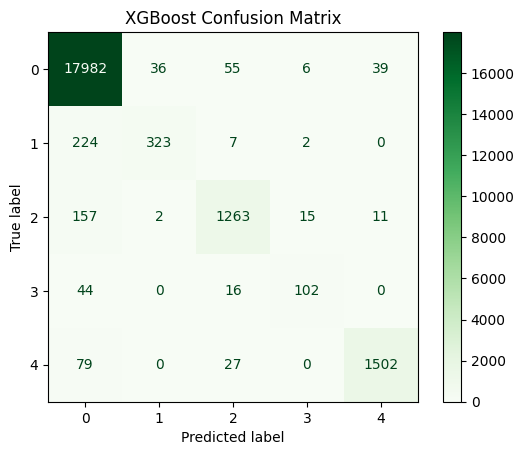

In [16]:

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train_anova, y_train)

y_pred_xgb = xgb_model.predict(X_test_anova)


print("\n==============================")
print("XGBOOST RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("XGBoost Confusion Matrix")
plt.show()



*IMPORTANT! Notice the **recall** values (recall measures how many true pathological cases were successfully detected by the model).*

*In medical applications, low recall can be dangerous because it means that diseased patients may remain undetected (false negatives). For this reason, **improving recall for minority arrhythmia classes is often more important than maximizing overall accuracy alone.***

To further **improve detection of minority arrhythmia classes**, we will introduce **sample weights** - assigns higher importance to underrepresented classes and lower importance to dominant classes during the learning process.


XGBOOST RESULTS
Accuracy: 0.9529965284122054

Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      0.97      0.98     18118
         1.0       0.62      0.72      0.67       556
         2.0       0.81      0.92      0.86      1448
         3.0       0.61      0.76      0.67       162
         4.0       0.92      0.95      0.94      1608

    accuracy                           0.95     21892
   macro avg       0.79      0.86      0.82     21892
weighted avg       0.96      0.95      0.95     21892



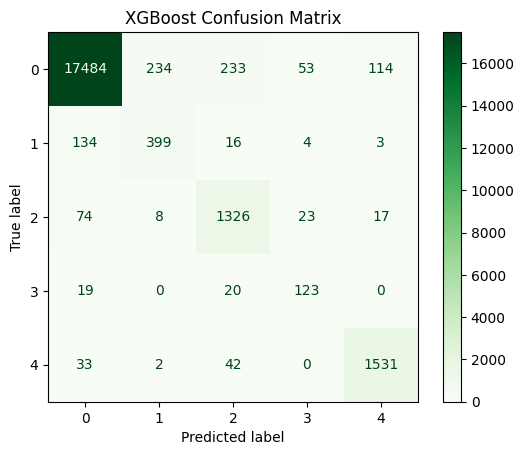

In [17]:
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

# COMPUTE BALANCED SAMPLE WEIGHTS
sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_train
)



xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(
    X_train_anova,
    y_train,
    sample_weight=sample_weights  #use weights
)

y_pred_xgb = xgb_model.predict(X_test_anova)

print("\n==============================")
print("XGBOOST RESULTS")
print("==============================")

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

cm = confusion_matrix(y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(cm)

disp.plot(cmap="Greens")

plt.title("XGBoost Confusion Matrix")
plt.show()



*Note: after introducing balanced sample weights, the **recall** values for minority arrhythmia classes improved noticeably, particularly for Classes 1 and 3.*

*The improvement in recall comes with a small decrease in overall accuracy and precision, which is a common trade-off in imbalanced biomedical datasets. In medical applications, this trade-off is often acceptable because missing pathological cases (false negatives) can be more problematic than producing some additional false alarms (false positives).*

#### Explainability

1. **Feature importance** - measures how useful a feature was during tree construction (how much it improved **decision splits** inside the model).

2. **Permutation importance** - measures how much model **performance decreases** when a feature is **randomly shuffled**.


<Figure size 1000x600 with 0 Axes>

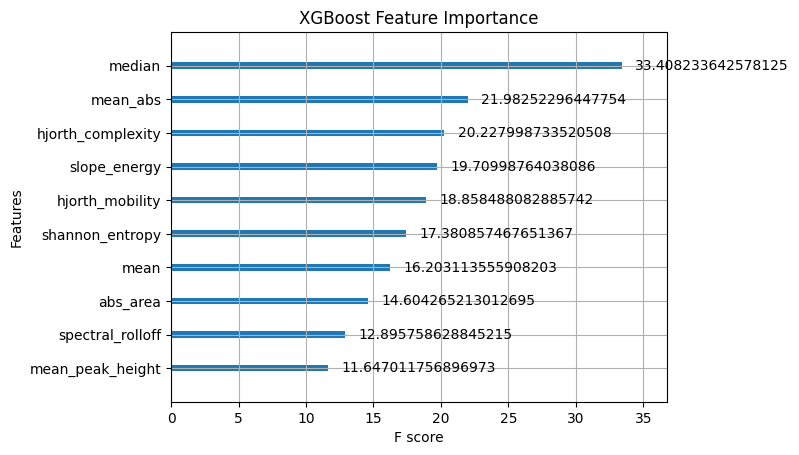

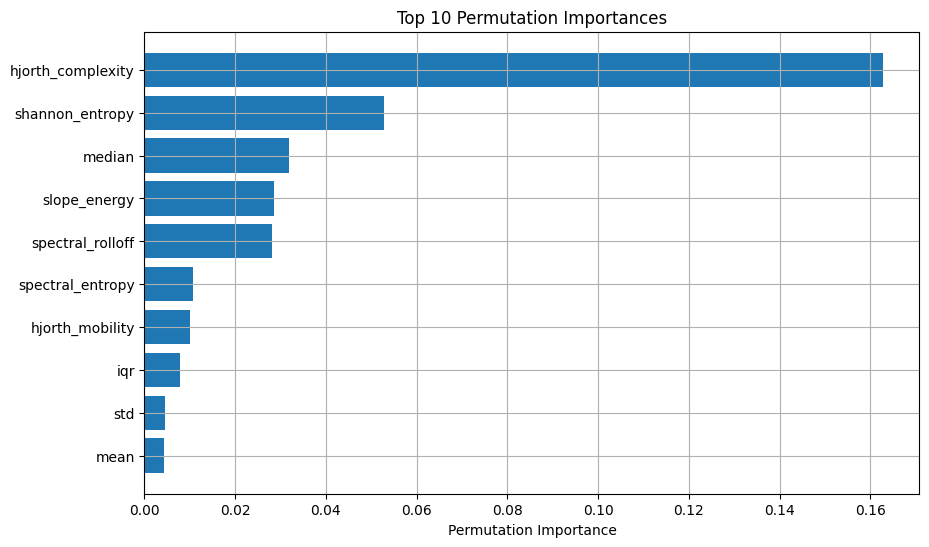

In [18]:

# ------------------------------------------------------------
# XGBoost Feature Importance
# ------------------------------------------------------------

xgb_model.get_booster().feature_names = list(anova_features)

plt.figure(figsize=(10,6))

plot_importance(
    xgb_model,
    importance_type="gain",
    max_num_features=10
)

plt.title("XGBoost Feature Importance")

plt.show()





# ============================================================
# PERMUTATION IMPORTANCE
# ============================================================
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    xgb_model,
    X_test_anova,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1_weighted"
)


perm_df = pd.DataFrame({
    "Feature": anova_features,
    "Importance_Mean": perm_importance.importances_mean,
    "Importance_STD": perm_importance.importances_std
})

perm_df = perm_df.sort_values(
    by="Importance_Mean",
    ascending=False
)


plt.figure(figsize=(10,6))

plt.barh(
    perm_df["Feature"][:10][::-1],
    perm_df["Importance_Mean"][:10][::-1]
)

plt.xlabel("Permutation Importance")
plt.title("Top 10 Permutation Importances")

plt.grid(True)

plt.show()



*The built-in XGBoost feature importance and permutation importance produce similar but not identical rankings because they measure different aspects of model behavior. The results suggest that some **statistical features** such as mean, median, and abs_area **contain partially overlapping information**, since their permutation importance is lower despite high XGBoost importance. In contrast, **hjorth_complexity** remains highly important in both analyses, indicating that it provides uniquely valuable information for ECG classification.*